In [1]:
import cv2
import glob
import os
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


## 1. Load images from Bike / Bicycle folders

In [2]:
import os
import cv2
import numpy as np

# Root folder containing the two class subfolders -- CHANGE THIS to your actual path
base_folder = r"C:\Users\sunil\Downloads\Bikes and Bicycle"

# Map: subfolder name -> class label
classes = {
    "Bike": "bike",
    "Bicycle": "bicycle"
}

X = []
y = []

for subfolder, label in classes.items():
    folder_path = os.path.join(base_folder, subfolder)
    for file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file)
        img = cv2.imread(img_path)
        if img is None:
            continue  # skip unreadable / non-image files
        img = cv2.resize(img, (150, 150))

        X.append(img)
        y.append(label)

X = np.array(X)
y = np.array(y)


In [3]:
X.shape

(36, 150, 150, 3)

In [4]:
y.shape

(36,)

## 2. Data augmentation

In [5]:
import cv2
import numpy as np
import albumentations as A

transform = A.Compose([
    A.VerticalFlip(p=0.1),           # neither bikes nor bicycles are ever upside down
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.GaussNoise(p=0.5),
    A.MedianBlur(p=0.3)
])


In [6]:
X_aug = []
y_aug = []

for img, label in zip(X, y):
    for _ in range(20):
        augmented = transform(image=img)
        X_aug.append(augmented["image"])
        y_aug.append(label)

X_aug = np.array(X_aug)
y_aug = np.array(y_aug)

print(X_aug.shape)
print(y_aug.shape)


(720, 150, 150, 3)
(720,)


In [7]:
X_final = np.concatenate((X, X_aug), axis=0)
y_final = np.concatenate((y, y_aug), axis=0)

print(X_final.shape)
print(y_final.shape)


(756, 150, 150, 3)
(756,)


## 3. Encode labels and normalize pixels

In [8]:
label = LabelEncoder()
y_encoded = label.fit_transform(y_final)

print(label.classes_)     # e.g. ['bicycle' 'bike']
print(y_encoded[:20])


['bicycle' 'bike']
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0]


In [9]:
X_final = X_final.astype("float32") / 255.0

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_encoded, test_size=0.2, random_state=42
)


In [11]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(604, 150, 150, 3)
(152, 150, 150, 3)
(604,)
(152,)


## 4. Build the CNN model

In [12]:
model = Sequential([
    Conv2D(64, (3,3), activation='relu', input_shape=(150,150,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.25),
    Dense(2, activation='softmax')   # 2 classes: bike vs bicycle
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)


## 5. Train

In [13]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    callbacks=[early_stop]
)


Epoch 1/10


19/19 [==============================] - 25s 1s/step - loss: 1.2008 - accuracy: 0.5927 - val_loss: 0.5395 - val_accuracy: 0.7697
Epoch 2/10
19/19 [==============================] - 23s 1s/step - loss: 0.4357 - accuracy: 0.8179 - val_loss: 0.2660 - val_accuracy: 0.9211
Epoch 3/10
19/19 [==============================] - 23s 1s/step - loss: 0.1618 - accuracy: 0.9470 - val_loss: 0.2066 - val_accuracy: 0.9342
Epoch 4/10
19/19 [==============================] - 24s 1s/step - loss: 0.0732 - accuracy: 0.9785 - val_loss: 0.2123 - val_accuracy: 0.9474
Epoch 5/10
19/19 [==============================] - 24s 1s/step - loss: 0.0752 - accuracy: 0.9719 - val_loss: 0.1504 - val_accuracy: 0.9539
Epoch 6/10
19/19 [==============================] - 22s 1s/step - loss: 0.0255 - accuracy: 0.9917 - val_loss: 0.1913 - val_accuracy: 0.9605
Epoch 7/10
19/19 [==============================] - 24s 1s/step - loss: 0.0199 - accuracy: 0.9950 - val_loss: 0.2243 - val_accuracy: 0.9474
Epoch 8/10
19/19 [

## 6. Evaluate on the held-out test set

In [14]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc*100:.2f}%")


5/5 [==============================] - 1s 121ms/step - loss: 0.1504 - accuracy: 0.9539
Test Accuracy: 95.39%


## 7. Prediction

In [15]:
img_path = r"C:\Users\sunil\Downloads\WhatsApp Image 2026-07-23 at 12.40.51 PM.jpeg"  

img = cv2.imread(img_path)
img = cv2.resize(img, (150, 150))
img = img.astype("float32") / 255.0   

img = np.expand_dims(img, axis=0)  


1/1 [==============================] - 0s 284ms/step
[[0.2329538 0.7670463]]
Predicted Label: Image Not Recognized / Not Found
Confidence: 76.70%


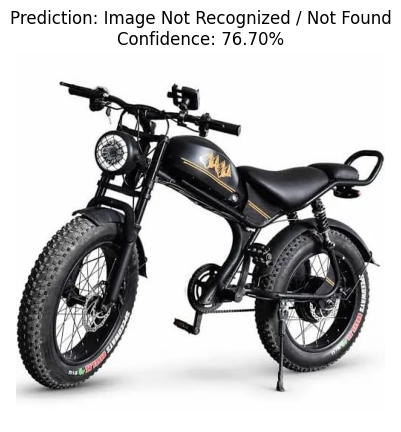

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

# Predict
prediction = model.predict(img)
print(prediction)

# Get predicted class index and confidence
predicted_class = np.argmax(prediction, axis=1)[0]
confidence = np.max(prediction) * 100  # confidence as percentage

THRESHOLD = 100.0 

image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)

if confidence < THRESHOLD:
    predicted_label = "Image Not Recognized / Not Found"
else:
    predicted_label = label.inverse_transform([predicted_class])[0]

print("Predicted Label:", predicted_label)
print(f"Confidence: {confidence:.2f}%")

plt.imshow(image)
plt.title(f"Prediction: {predicted_label}\nConfidence: {confidence:.2f}%")
plt.axis("off")
plt.show()
